In [ ]:
### This script is used to analyze the 2p data of prism animals (V1)
### 1) Cell density and 2) cell size are calculated

In [1]:
cd "C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation"

C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation


**Load 2p data**

Fneu =  269000


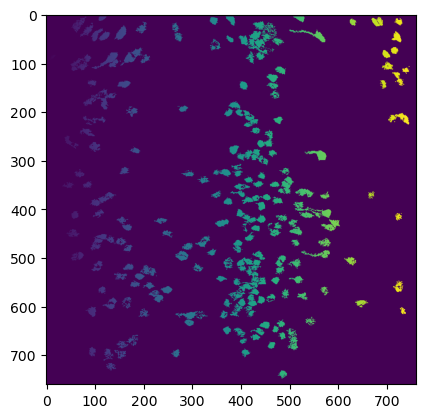

In [256]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Load 2p data
filepath = r'D:\V1_SpatialModulation\2p\250205_JSY_JSY041_PrismTest\TSeries-02052025-1306-Cousa-003\suite2p\plane0'

Fneu = np.load(os.path.join(filepath, 'Fneu.npy'), allow_pickle=True)
iscell = np.load(os.path.join(filepath, 'iscell.npy'), allow_pickle=True)
stat = np.load(os.path.join(filepath, 'stat.npy'), allow_pickle=True)
ops = np.load(os.path.join(filepath, 'ops.npy'), allow_pickle=True).item()
print('Fneu = ', np.size(Fneu))



usecells = iscell[:,0]==1
# FneuCell = Fneu[usecells,:]  # Use only cells that are classified as cells
FneuCellAvg = np.mean(Fneu, axis=1)  # Average over all cells

# print('iscell = ', np.size(iscell))
# print('FneuCell = ', np.size(FneuCell))
# print('usecell = ', np.size(usecells))
# print('stat = ', np.size(stat))
# print(FneuCellAvg.shape)

im = np.zeros((ops['Ly'], ops['Lx']))  # Create an empty image
ncells = len(stat)

for n in range(0, ncells):
    ypix = stat[n]['ypix'][~stat[n]['overlap']]
    xpix = stat[n]['xpix'][~stat[n]['overlap']]
    im[ypix, xpix] = xpix  # Assign xpix values to im for progressive color change along x-axis

im_rotated = np.rot90(im, k=-1)
plt.imshow(im, cmap='viridis')  # Use a colormap that shows progressive change
# plt.imshow(im_rotated, cmap='viridis')  # Use a colormap that shows progressive change
# plt.colorbar().ax.invert_yaxis()
plt.show()

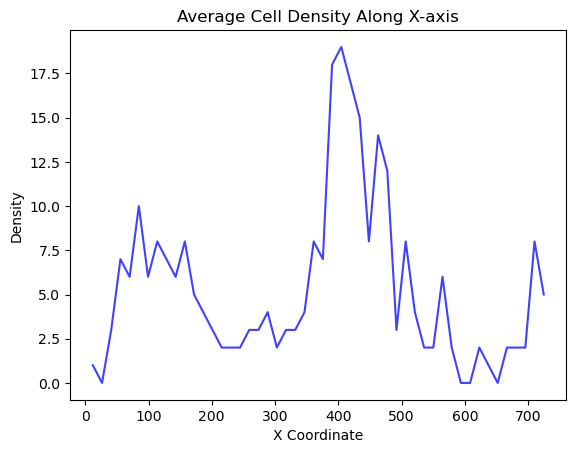

In [298]:
# Extract the median coordinates of each cell
med_coords = np.array([cell['med'] for cell in stat])

# Calculate the density along the x-axis
density, bins = np.histogram(med_coords[:, 1], bins=50)

# Plot the average cell density along the x-axis
plt.figure()
plt.plot(bins[:-1], density, alpha=0.75, color='blue')
# plt.axvline(avg_density_x, color='red', linestyle='dashed', linewidth=1)
plt.title('Average Cell Density Along X-axis')
plt.xlabel('X Coordinate')
plt.ylabel('Density')
plt.show()

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_29480\2619745104.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


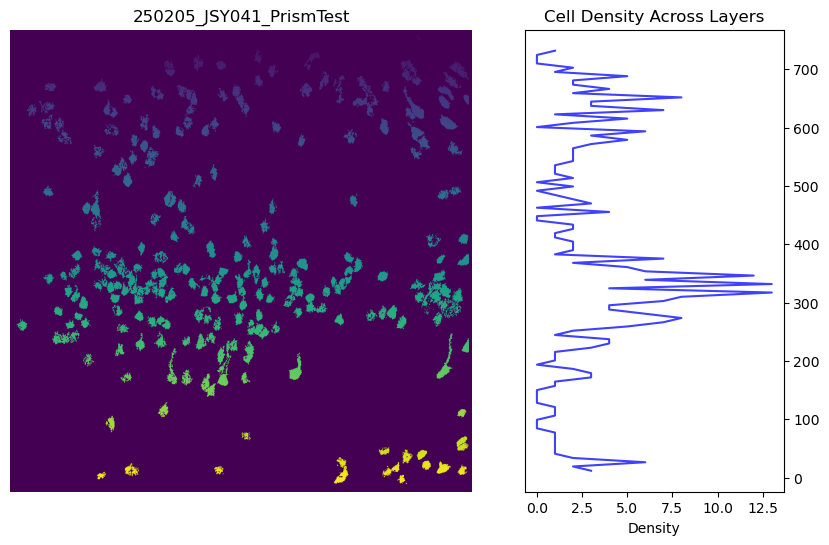

In [132]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [3, 1], 'wspace': -0.2})
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()

# Rotate the first plot
im_rotated = np.rot90(im, k=-1)
ax1.imshow(im_rotated, cmap='viridis')
ax1.set_title('250205_JSY041_PrismTest')
ax1.axis('off')

# Rotate the second plot
density_rotated = np.rot90(density.reshape(-1, 1), k=-1)
ax2.plot(density_rotated[0], bins[:-1], alpha=0.75, color='blue')
ax2.set_title('Cell Density Across Layers')
ax2.set_xlabel('Density')

plt.tight_layout()
plt.show()


Text(0.5, 0.98, 'Fneu along x-axis')

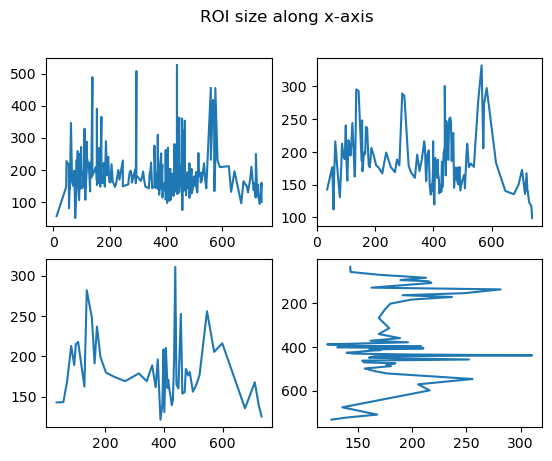

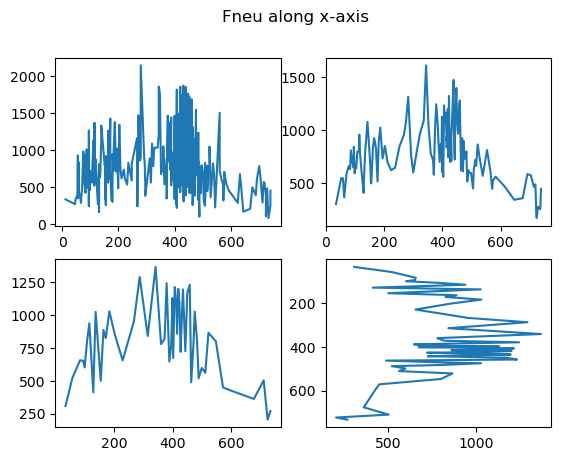

In [286]:
### calculate ROI size and Fneu along the x-axis
# Extract the median coordinates of each cell
med_coords = np.array([cell['med'][1] for cell in stat])

# Extract the ROI size of each cell
ROIsize = np.array([cell['npix'] for cell in stat])

# Sort the median coordinates and ROI sizes/F_neu
sort_med_coords_indice = np.argsort(med_coords)
sort_ROIsize = ROIsize[sort_med_coords_indice]
sort_Fneu = FneuCellAvg[sort_med_coords_indice]

# Calculate the average of every 3 sorted ROI sizes/F_neu and median coordinates
avg_ROIsize = [np.mean(sort_ROIsize[i:i+3]) for i in range(0, len(sort_ROIsize), 2)]
avg_med_coords = [np.mean(med_coords[sort_med_coords_indice][i:i+3]) for i in range(0, len(sort_med_coords_indice), 2)]
avg_Fneu = [np.mean(sort_Fneu[i:i+3]) for i in range(0, len(sort_Fneu), 2)]

# Calculate the average of every 3 sorted ROI sizes/F_neu and median coordinates
avg5_ROIsize = [np.mean(sort_ROIsize[i:i+3]) for i in range(0, len(sort_ROIsize), 5)]
avg5_med_coords = [np.mean(med_coords[sort_med_coords_indice][i:i+3]) for i in range(0, len(sort_med_coords_indice), 5)]
avg5_Fneu = [np.mean(sort_Fneu[i:i+3]) for i in range(0, len(sort_Fneu), 5)]

figure, ax = plt.subplots(2,2)
ax[0,0].plot(med_coords[sort_med_coords_indice],sort_ROIsize)
ax[0,1].plot(avg_med_coords, avg_ROIsize)
ax[1,0].plot(avg5_med_coords, avg5_ROIsize)
ax[1,1].plot(avg5_ROIsize, avg5_med_coords)
ax[1,1].invert_yaxis()
figure.suptitle('ROI size along x-axis')

figure, ax = plt.subplots(2,2)
ax[0,0].plot(med_coords[sort_med_coords_indice],sort_Fneu)
ax[0,1].plot(avg_med_coords, avg_Fneu)
ax[1,0].plot(avg5_med_coords, avg5_Fneu)
ax[1,1].plot(avg5_Fneu, avg5_med_coords)
ax[1,1].invert_yaxis()
figure.suptitle('Fneu along x-axis')

In [285]:
from scipy.ndimage import gaussian_filter1d

def smooth(data, sigma):
    return gaussian_filter1d(data, sigma=sigma)

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_29480\139111215.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


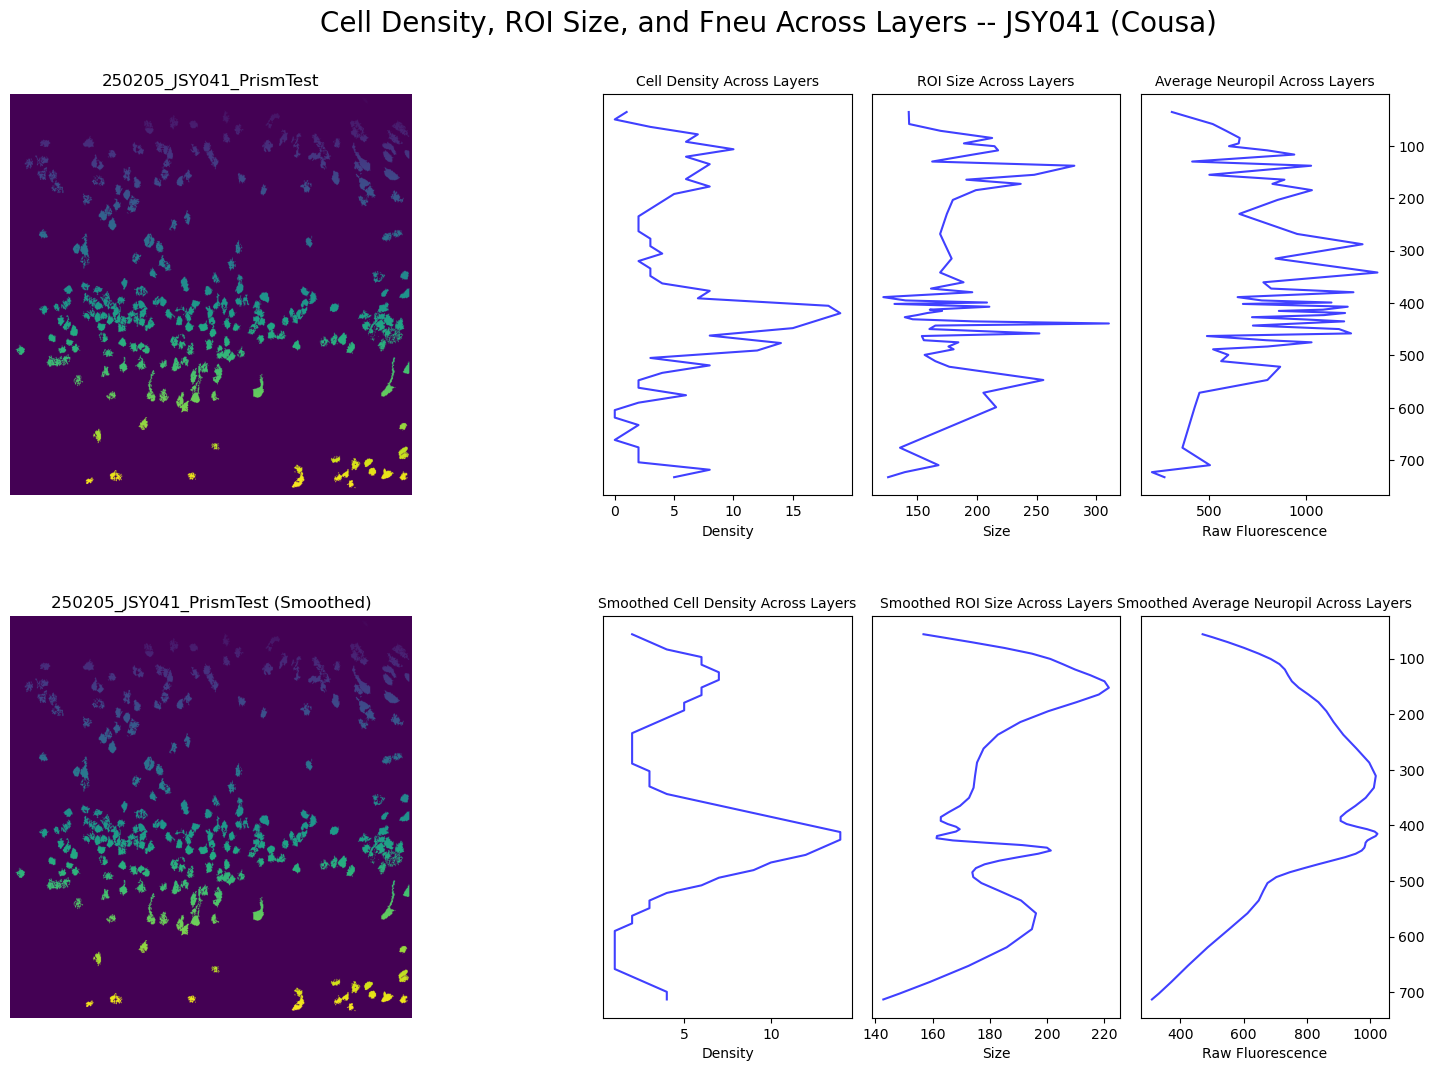

In [313]:
fig, axes = plt.subplots(2, 4, figsize=(20, 12), gridspec_kw={'width_ratios': [3, 1, 1, 1], 'wspace': 0.055, 'hspace': 0.3})

# Plot the ROIs
im_rotated = np.rot90(im, k=-1)
axes[0, 0].imshow(im_rotated, cmap='viridis')
axes[0, 0].set_title('250205_JSY041_PrismTest')
axes[0, 0].axis('off')

# Plot the average cell density along the x-axis
density_rotated = np.rot90(density.reshape(-1, 1), k=-1)
axes[0, 1].plot(density_rotated[0][:len(bins[:-1])], bins[:-1], alpha=0.75, color='blue')
axes[0, 1].set_title('Cell Density Across Layers', fontsize=10)
axes[0, 1].set_xlabel('Density', fontsize=10)
axes[0, 1].set_yticks([])  # Remove y-axis

# Plot the ROI size along the x-axis
axes[0, 2].plot(avg5_ROIsize, avg5_med_coords, alpha=0.75, color='blue')
axes[0, 2].invert_yaxis()
axes[0, 2].set_title('ROI Size Across Layers', fontsize=10)
axes[0, 2].set_xlabel('Size', fontsize=10)
axes[0, 2].set_yticks([])  # Remove y-axis labels/ticks on the left

# Plot the average Fneu along the x-axis
axes[0, 3].plot(avg5_Fneu, avg5_med_coords, alpha=0.75, color='blue')
axes[0, 3].invert_yaxis()
axes[0, 3].set_title('Average Neuropil Across Layers', fontsize=10)
axes[0, 3].set_xlabel('Raw Fluorescence', fontsize=10)
axes[0, 3].yaxis.set_label_position("right")
axes[0, 3].yaxis.tick_right()

# Smooth the data
sigma = 2
smooth_density = smooth(density, sigma)
smooth_avg5_ROIsize = smooth(avg5_ROIsize, sigma)
smooth_avg5_Fneu = smooth(avg5_Fneu, sigma)
smooth_avg5_med_coords = smooth(avg5_med_coords, sigma)

# Plot the smoothed ROIs
axes[1, 0].imshow(im_rotated, cmap='viridis')
axes[1, 0].set_title('250205_JSY041_PrismTest (Smoothed)')
axes[1, 0].axis('off')

# Plot the smoothed cell density along the x-axis
density_rotated = np.rot90(smooth_density.reshape(-1, 1), k=-1)
axes[1, 1].plot(density_rotated[0][:len(bins[:-sigma])], bins[:-sigma], alpha=0.75, color='blue')
axes[1, 1].set_title('Smoothed Cell Density Across Layers', fontsize=10)
axes[1, 1].set_xlabel('Density', fontsize=10)
axes[1, 1].set_yticks([])  # Remove y-axis

# Plot the smoothed ROI size along the x-axis
axes[1, 2].plot(smooth_avg5_ROIsize, smooth_avg5_med_coords, alpha=0.75, color='blue')
axes[1, 2].invert_yaxis()
axes[1, 2].set_title('Smoothed ROI Size Across Layers', fontsize=10)
axes[1, 2].set_xlabel('Size', fontsize=10)
axes[1, 2].set_yticks([])  # Remove y-axis labels/ticks on the left

# Plot the smoothed average Fneu along the x-axis
axes[1, 3].plot(smooth_avg5_Fneu, smooth_avg5_med_coords, alpha=0.75, color='blue')
axes[1, 3].invert_yaxis()
axes[1, 3].set_title('Smoothed Average Neuropil Across Layers', fontsize=10)
axes[1, 3].set_xlabel('Raw Fluorescence', fontsize=10)
axes[1, 3].yaxis.set_label_position("right")
axes[1, 3].yaxis.tick_right()

fig.suptitle('Cell Density, ROI Size, and Fneu Across Layers -- JSY041 (Cousa_2)', fontsize=20, x=0.59, y=0.95)

plt.tight_layout()
plt.show()
